In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import*
import qkd_sf as qsf
from importlib import reload
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "notebook"

def reload_protocols():
    reload(qsf)

In [167]:
eta_grid = np.linspace(0, 1, 51)
keylen = 50000
var_a_grid = np.linspace(0.001, 100, 101)
V_grid = np.linspace(0.1, 1, 51)

### Mutual Information (same for DR/RR)

### Theoretical Results

In [168]:
reload_protocols()
I_per_eta_dict_th = qsf.get_mutual_information_th(var_a_grid, V_grid, eta_grid)

Progress: 51/51

### MC Produce

In [160]:
for j, eta in enumerate(eta_grid):
    I_grid_x = np.zeros((len(var_a_grid), len(V_grid)))
    for i,v in enumerate(V_grid):
        I, I_x, I_p = qsf.MC_I_AB(var_a_grid, eta, keylen, v)
        I_grid_x[:,i] = I_x
        print(f"\rProgress: {i+1}/{len(V_grid)}", end="", flush=True)

    np.savez(f"data/QKD_I_V{len(V_grid)}_Va{len(var_a_grid)}_samples{keylen}_eta{eta}.npz", I_grid_x=I_grid_x, V_grid=V_grid, var_a_grid=var_a_grid, samples=keylen, eta=eta)
    print(f"\rProgress: {j+1}/{len(eta_grid)}", end="", flush=True)

Progress: 1/151

### MC Load

In [161]:
I_per_eta_dict_MC = {}

for j, eta in enumerate(eta_grid):
    data_I = np.load(f"data/QKD_I_V{len(V_grid)}_Va{len(var_a_grid)}_samples{keylen}_eta{eta}.npz")
    I_grid_x = data_I["I_grid_x"]
    I_per_eta_dict_MC[f'eta_{eta}'] = I_grid_x

## RR Protocol

### Holevo Bound

In [169]:
reload_protocols()
chix_per_eta_dict_RR = qsf.get_Holevo_bound(var_a_grid, V_grid, eta_grid, 'RR')

Progress: 51/51

### 3D Plots

In [170]:
reload_protocols()
b = 0.9
eta = 0.6

qsf.plot_I_chi(eta, V_grid, var_a_grid, I_per_eta_dict_th, chix_per_eta_dict_RR, I_per_eta_dict_MC, MC=False)

In [171]:
reload_protocols()
qsf.plot_K(b, eta, var_a_grid, V_grid, I_per_eta_dict_th, I_per_eta_dict_MC, chix_per_eta_dict_RR, MC=False)

### Plot Mutual Information & Holevo Bound

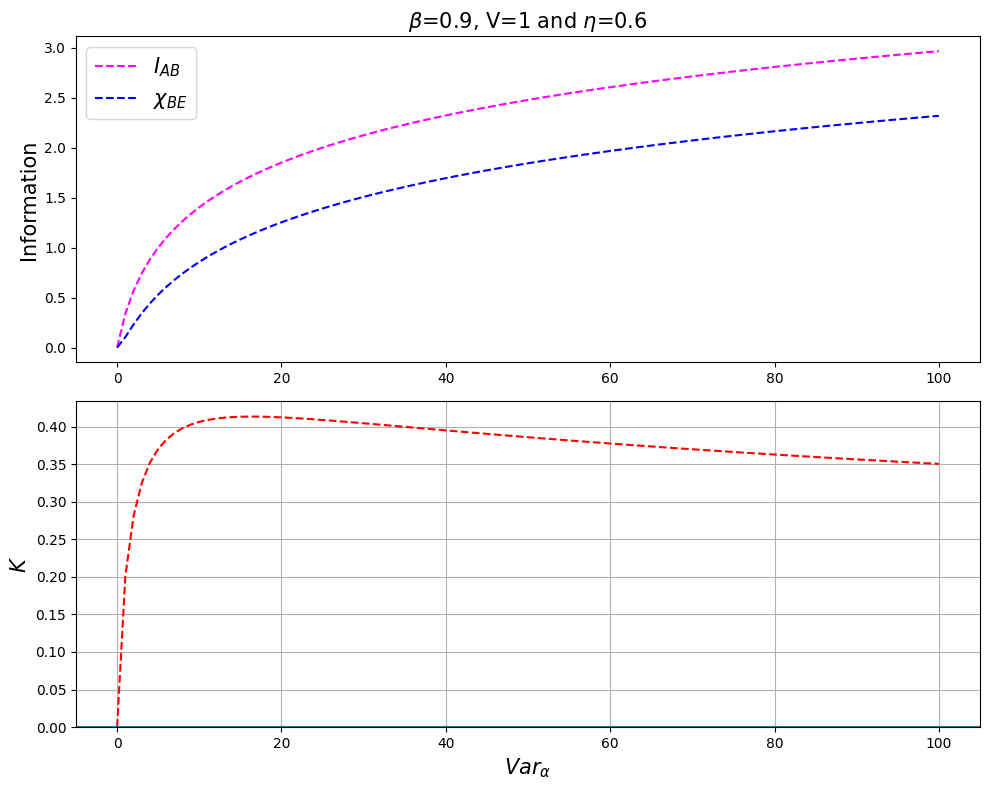

In [172]:
reload_protocols()
V = 1
qsf.plot_2D_chi_I_K(b, eta, V, var_a_grid, V_grid, I_per_eta_dict_th, I_per_eta_dict_MC, chix_per_eta_dict_RR)

### Plot K regions

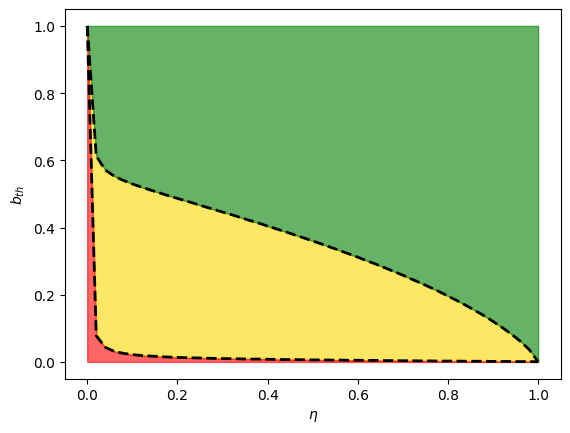

In [173]:
reload_protocols()
qsf.plot_K_regions(eta_grid, I_per_eta_dict_th, chix_per_eta_dict_RR)

## DR protocol

### Holevo Bound

In [174]:
reload_protocols()
chix_per_eta_dict_DR = qsf.get_Holevo_bound(var_a_grid, V_grid, eta_grid, 'DR')

Progress: 51/51

### 3D Plots

In [178]:
reload_protocols()
b = 0.9
eta = 0.6

qsf.plot_I_chi(eta,  V_grid, var_a_grid, I_per_eta_dict_th, chix_per_eta_dict_DR, I_per_eta_dict_MC, MC=True)

hi


In [180]:
reload_protocols()
qsf.plot_K(b, eta, var_a_grid, V_grid, I_per_eta_dict_th, I_per_eta_dict_MC, chix_per_eta_dict_DR, MC=False)

### Plot Mutual Information & Holevo Bound

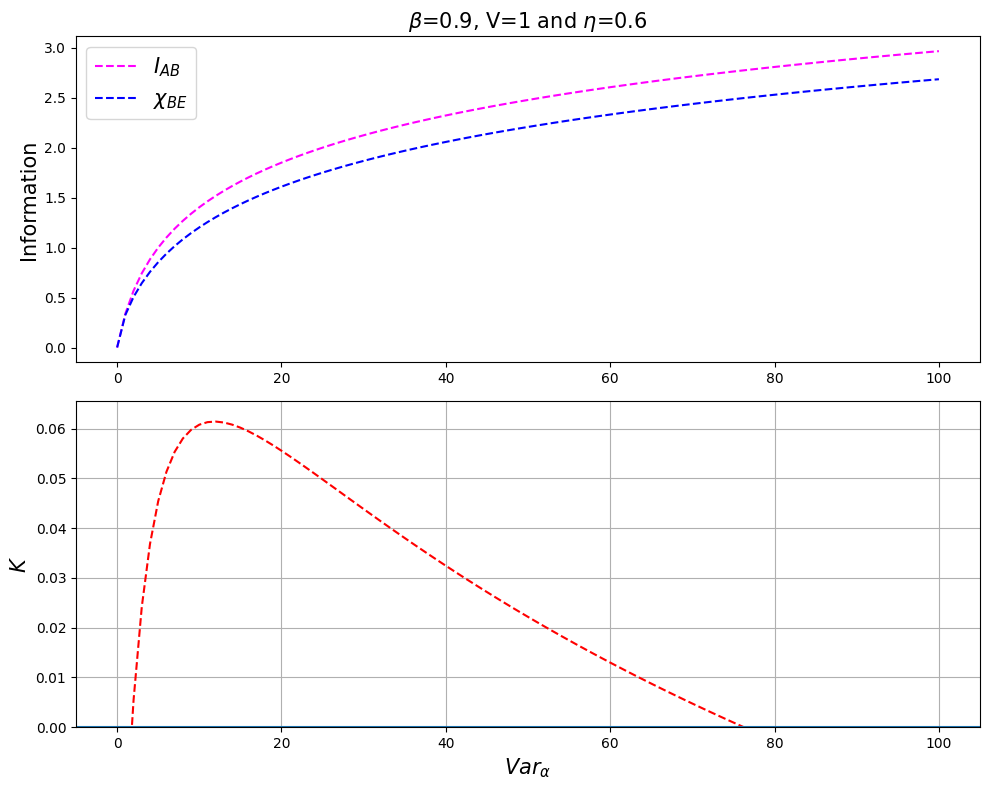

In [181]:
reload_protocols()
V = 1
b = 0.9
qsf.plot_2D_chi_I_K(b, eta, V, var_a_grid, V_grid, I_per_eta_dict_th, I_per_eta_dict_MC, chix_per_eta_dict_DR)

### Plot K regions

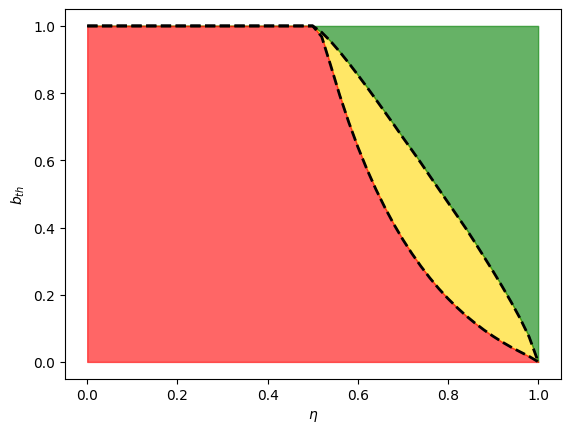

In [182]:
reload_protocols()
qsf.plot_K_regions(eta_grid, I_per_eta_dict_th, chix_per_eta_dict_DR)